In [1]:
from __future__ import print_function

import keras, os
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Dropout
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization as BN
from keras.layers import GaussianNoise as GN
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from keras.utils import np_utils
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf

from keras.callbacks import LearningRateScheduler as LRS
from keras.preprocessing.image import ImageDataGenerator

In [2]:
batch_size = 128
num_classes = 10
epochs = 100

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255
x_test /= 255

y_train = keras.utils.np_utils.to_categorical(y_train, num_classes)
y_test = keras.utils.np_utils.to_categorical(y_test, num_classes)

170498071/170498071 [==============================] - 3s 0us/step


In [4]:
datagen = ImageDataGenerator(
    width_shift_range=0.15,
    height_shift_range=0.15,
    rotation_range=15,
    horizontal_flip=True)

In [5]:
def CBGN(model,filters,ishape=0, maxPool=False):
  if (ishape!=0):
    model.add(Conv2D(filters, (3, 3), padding='same',
                 input_shape=ishape))
  else:
    model.add(Conv2D(filters, (3, 3), padding='same'))
  
  model.add(BN())
  model.add(GN(0.25))
  model.add(Activation('relu'))
  if maxPool:
    model.add(MaxPooling2D(pool_size=(2, 2)))
  
  
  return model

In [6]:
model = Sequential()

model=CBGN(model,64,x_train.shape[1:])
model.add(Dropout(0.1))
model=CBGN(model,64,maxPool=True)

model=CBGN(model,128)
model.add(Dropout(0.2))
model=CBGN(model,128,maxPool=True)

model=CBGN(model,256)
model.add(Dropout(0.2))
model=CBGN(model,256)
model.add(Dropout(0.2))
model=CBGN(model,256,maxPool=True)

model=CBGN(model,512)
model.add(Dropout(0.3))
model=CBGN(model,512)
model.add(Dropout(0.3))
model=CBGN(model,512,maxPool=True)

model=CBGN(model,512)
model.add(Dropout(0.3))
model=CBGN(model,512)
model.add(Dropout(0.3))
model=CBGN(model,512,maxPool=True)

model.add(Flatten())
model.add(Dense(512))
model.add(BN())
model.add(GN(0.30))
model.add(Activation('relu'))
model.add(Dropout(0.4))

model.add(Dense(256))
model.add(BN())
model.add(GN(0.35))
model.add(Activation('relu'))
model.add(Dropout(0.4))

model.add(Dense(num_classes))
model.add(Activation('softmax'))


model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        1792      
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 64)       256       
 ormalization)                                                   
                                                                 
 gaussian_noise (GaussianNoi  (None, 32, 32, 64)       0         
 se)                                                             
                                                                 
 activation (Activation)     (None, 32, 32, 64)        0         
                                                                 
 dropout (Dropout)           (None, 32, 32, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        3

In [7]:
#opt = SGD(learning_rate=0.1, momentum=0.9)
opt = Adam(learning_rate=0.01)

model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

In [8]:
def scheduler(epoch):
    if epoch < 25:
        return .01
    elif epoch < 50:
        return 0.001
    else:
        return 0.0001

#set_lr = LRS(scheduler)
set_lr = ReduceLROnPlateau(monitor='val_loss', patience=10)

In [9]:
history=model.fit(datagen.flow(x_train, y_train,batch_size=batch_size),
                            steps_per_epoch=len(x_train) / batch_size, 
                            epochs=epochs,
                            validation_data=(x_test, y_test),
                            callbacks=[set_lr],
                            verbose=1)

Epoch 1/100
390/390 [==============================] - 53s 97ms/step - loss: 2.1360 - accuracy: 0.1838 - val_loss: 2.5131 - val_accuracy: 0.1521 - lr: 0.0100
Epoch 2/100
390/390 [==============================] - 36s 93ms/step - loss: 1.8859 - accuracy: 0.2524 - val_loss: 2.4689 - val_accuracy: 0.2397 - lr: 0.0100
Epoch 3/100
390/390 [==============================] - 36s 93ms/step - loss: 1.6592 - accuracy: 0.3475 - val_loss: 2.4439 - val_accuracy: 0.3666 - lr: 0.0100
Epoch 4/100
390/390 [==============================] - 36s 91ms/step - loss: 1.4850 - accuracy: 0.4322 - val_loss: 6.5423 - val_accuracy: 0.2022 - lr: 0.0100
Epoch 5/100
390/390 [==============================] - 38s 96ms/step - loss: 1.3535 - accuracy: 0.5040 - val_loss: 1.6163 - val_accuracy: 0.5166 - lr: 0.0100
Epoch 6/100
390/390 [==============================] - 36s 91ms/step - loss: 1.2258 - accuracy: 0.5615 - val_loss: 1.6426 - val_accuracy: 0.5500 - lr: 0.0100
Epoch 7/100
390/390 [==============================]

In [10]:
import matplotlib.pyplot as plt
def plot_evolution(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('')

313/313 [==============================] - 3s 10ms/step - loss: 0.2893 - accuracy: 0.9201
Test loss: 0.28932034969329834
Test accuracy: 0.9200999736785889


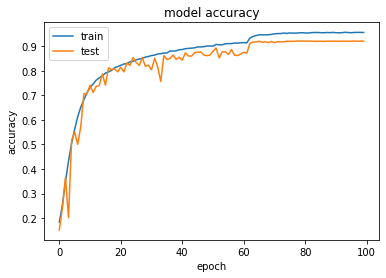

In [11]:
scores = model.evaluate(x_test, y_test, verbose=1)
plot_evolution(history)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])